# Beijing Air Quality Forecasting (PM2.5)

## Imports, dataset loading and cleaning

**TODO**: Right now the dataset loading is local. Ensure the dataset is accessible via Drive.

Before starting, we import the necessary libraries and define the functions that will ensure that the project works correctly.

In [3]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera
from statsmodels.tsa.arima.model import ARIMA

# Delete Python warnings to keep output clean
warnings.filterwarnings("ignore")

# Configure the visual style and size of the graphs
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 4)

# The date in the dataset is split into four columns, this function puts them together into a datetime column
def make_datetime(df):
    return pd.to_datetime(df[["year", "month", "day", "hour"]])

# Function to split the data into Train and Test sets. The test set is the last hours defined by the "horizon" variable
def train_test_split_ts(series, horizon):
    train = series.iloc[:-horizon]
    test = series.iloc[-horizon:]
    return train, test

# Function to add values to the NaNs avoiding data leakage (splitting train from test)
def impute_train_test(train, test):
    # Fill the points with a straight line and fill borders
    train_filled = train.copy()
    train_filled = train_filled.interpolate("time")
    train_filled = train_filled.ffill().bfill()

    # Look for the last train value
    test_filled = test.copy()
    test_filled = test_filled.ffill()
    if test_filled.isna().any():
        test_filled = test_filled.fillna(train_filled.iloc[-1])
    test_filled = test_filled.bfill()
    return train_filled, test_filled


def impute_train_test(train, test):

    train_filled = train.copy()

    # interpolate works for both Series and DataFrame
    train_filled = train_filled.interpolate("time").ffill().bfill()

    test_filled = test.copy()
    test_filled = test_filled.ffill()

    # FIX: works for both Series and DataFrame
    if test_filled.isna().to_numpy().any():
        test_filled = test_filled.fillna(train_filled.iloc[-1])

    test_filled = test_filled.bfill()

    return train_filled, test_filled

# Function to calculate the Mean Absolute Error
def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

# Function to calculate the Root Mean Squared Error
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

# Function to calculate the Mean Absolute Percentage Error
def mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = y_true != 0
    if not np.any(mask):
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# Function to calculate the R-squared (R2) score
def r2_score(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    if ss_tot == 0:
        return np.nan
    return 1 - (ss_res / ss_tot)

# This function copies what has happened in the stablished "period" variable
def seasonal_naive(train, horizon, period):
    last_season = train.iloc[-period:]
    reps = int(np.ceil(horizon / period))
    forecast = np.tile(last_season.values, reps)[:horizon]
    index = pd.date_range(train.index[-1] + pd.Timedelta(hours=1), periods=horizon, freq="h")
    return pd.Series(forecast, index=index)

# This function assumes that the future values will be the same as the past values
def last_value_naive(train, horizon):
    index = pd.date_range(train.index[-1] + pd.Timedelta(hours=1), periods=horizon, freq="h")
    return pd.Series([train.iloc[-1]] * horizon, index=index)

# This function basically follows the inclination that the line joining the first data to the last data
def drift_method(train, horizon):
    if len(train) < 2:
        return last_value_naive(train, horizon)
    slope = (train.iloc[-1] - train.iloc[0]) / (len(train) - 1)
    steps = np.arange(1, horizon + 1)
    index = pd.date_range(train.index[-1] + pd.Timedelta(hours=1), periods=horizon, freq="h")
    return pd.Series(train.iloc[-1] + slope * steps, index=index)

# This function predicts using the mean of the train set for the entire horizon
def mean_naive(train, horizon):
    index = pd.date_range(train.index[-1] + pd.Timedelta(hours=1), periods=horizon, freq="h")
    return pd.Series([train.mean()] * horizon, index=index)

We load the dataset, create the datetime column to use it as index and check its dimensions, the available stations and the date range of the dataset.

In [4]:
import pandas as pd
from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

# Google Drive ID for public sharing of the dataset
file_id = "1t5-q06bM_eOQeSO0qq7zuyV0t4i1j2Z1"
DATA_PATH = "air_quality.csv"

file = drive.CreateFile({"id": file_id})
file.GetContentFile(DATA_PATH)

df = pd.read_csv(DATA_PATH)
df.head()

ModuleNotFoundError: No module named 'google.colab'

In [5]:
DATA_PATH = "air_quality.csv"

df = pd.read_csv(DATA_PATH)
df["datetime"] = make_datetime(df)

print("Shape:", df.shape)
print("Stations:", sorted(df["station"].unique()))
print("Date range:", df["datetime"].min(), "to", df["datetime"].max())

df.head()

Shape: (35064, 19)
Stations: ['Aotizhongxin']
Date range: 2013-03-01 00:00:00 to 2017-02-28 23:00:00


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin,2013-03-01 00:00:00
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin,2013-03-01 01:00:00
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin,2013-03-01 02:00:00
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin,2013-03-01 03:00:00
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin,2013-03-01 04:00:00


We isolate the monitoring station although the dataset we are using has just one. Since there are more datasets available on its Kaggle page, this will help us if we change it.

We also select the target variable, sort by datetime and make it the index. Then we introduce NaNs where timestamps are missing and check their rate.

After this, we impute data TEMPORARILY just for the plots, not for modeling, to avoid data leakage.

In [6]:
STATION = "Aotizhongxin"
TARGET = "PM2.5"

station_df = df[df["station"] == STATION].copy()
station_df = station_df.sort_values("datetime").set_index("datetime")

# Inject NaNs
series = station_df[TARGET].asfreq("h")

print("Series length:", len(series))
print("Missing values:", int(series.isna().sum()))
print("Missing rate:", round(series.isna().mean() * 100, 2), "%")

# Fill only for the plots
series_filled = series.interpolate("time").ffill().bfill()

Series length: 35064
Missing values: 925
Missing rate: 2.64 %


## Time series analysis

To better understand the behaviour of the PM2.5 we visualize the time series at three different temporal resolutions, helping to isolate the general tendency from the ups and downs of the daily routines.

The first graph groups the hourly data into days by computing the mean. This removes the noise of the hours and allows us to see the macro tendency.

In the second graph we zoom into January and February, 2016. As mentioned in the project proposal, our theory is that it's in these months when the PM2.5 will go up because of the use of carbon for heating.

The third graph takes the data from the whole date range (4 years) and groups them into the hour of the day (0 to 23) by computing the mean. This way we can see how a normal day behaves.

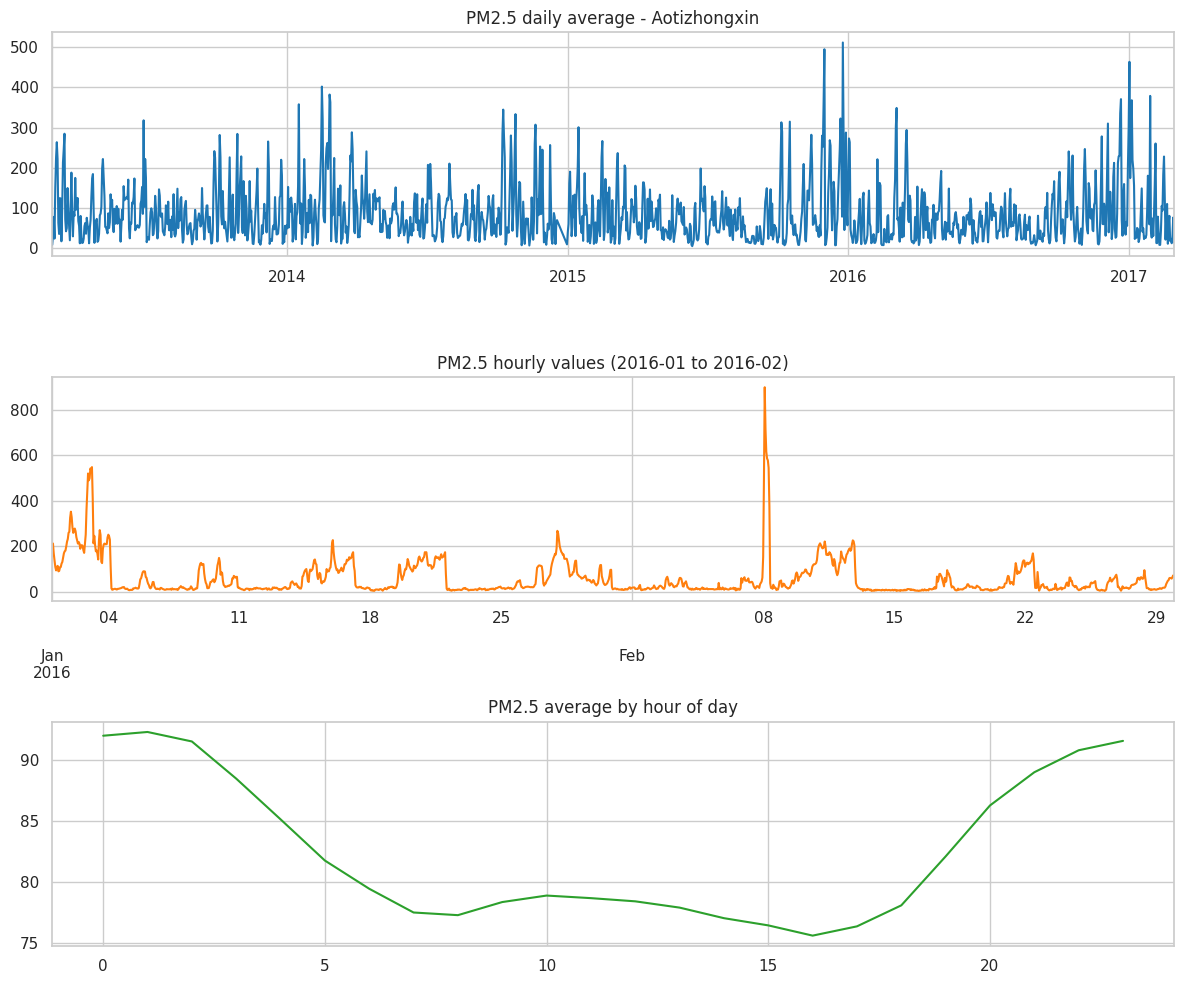

In [7]:
series_daily = series_filled.resample("D").mean()

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

series_daily.plot(ax=axes[0], color="tab:blue")
axes[0].set_title(f"{TARGET} daily average - {STATION}")

series_filled["2016-01":"2016-02"].plot(ax=axes[1], color="tab:orange")
axes[1].set_title(f"{TARGET} hourly values (2016-01 to 2016-02)")

hourly_profile = series_filled.groupby(series_filled.index.hour).mean()
hourly_profile.plot(ax=axes[2], color="tab:green")
axes[2].set_title(f"{TARGET} average by hour of day")

for ax in axes:
    ax.set_xlabel("")

plt.tight_layout()

The first plot shows clear cyclical peaks. The highest concentrations of PM2.5 occur during winter months (often exceeding 300-400 $\mu g/m^3$). This supports our theory that the increased coal combustion for heating and the thermal inversion that trap the pollutants near the surface make the PM2.5 go up during the winter months.

The second plot could support another theory we had: that the pollution could suddenly drop due to wash-out effects like rain or strong wind from the north. It is visible how the PM2.5 concentration rises for some days and suddenly falls, then builds up again. Seeing this, short horizon forecasts must handle sudden jumps.

The last plot shows clearly how the PM2.5 concentration peaks during the night and early morning (midnight to 2:00 AM, exceeding 90 $\mu g/m^3$). The air quality reaches its best values during mid-afternoon. This validates the presence of a daily seasonal component.

Now, we split the Trend, the Seasonal and the Residuals but instead of using the hourly data we have, we will make it daily (we tried to plot it with the original data but just a blue block was displayed). We use a cycle of 365 days.

We check if it is stationary with the ADF test in the original data and in the first difference.

We also analyze lag 1 (the last hour) and lag 24 (the last day) and check if including other variables (temperature, NO2 and CO) is worth it to help us predict better.

Finally, we graph the ACF and PACF of the differenced data looking at the previous 7 days.

Hourly series (filled) - ADF p-value: 0.0000
First difference - ADF p-value: 0.0000
Autocorr lag 1: 0.969
Autocorr lag 24: 0.402
Correlation with TEMP/NO2/CO:
TEMP   -0.128
NO2     0.685
CO      0.785
Name: PM2.5, dtype: float64


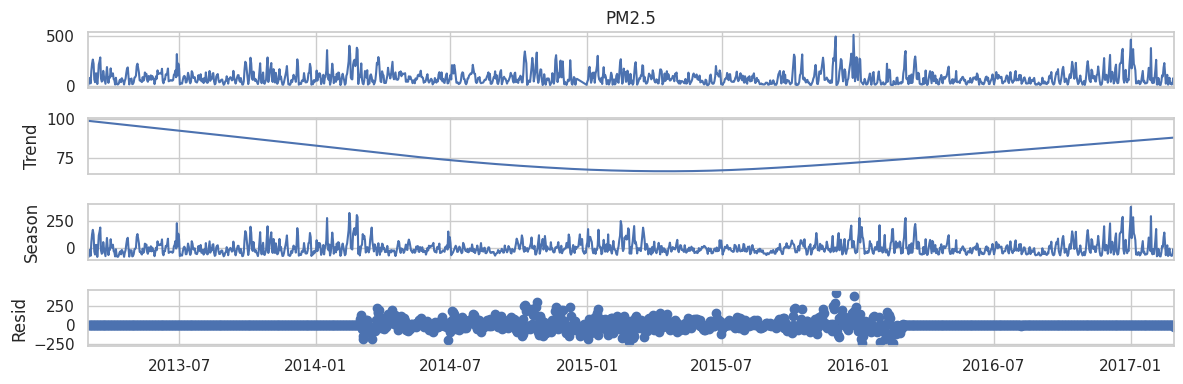

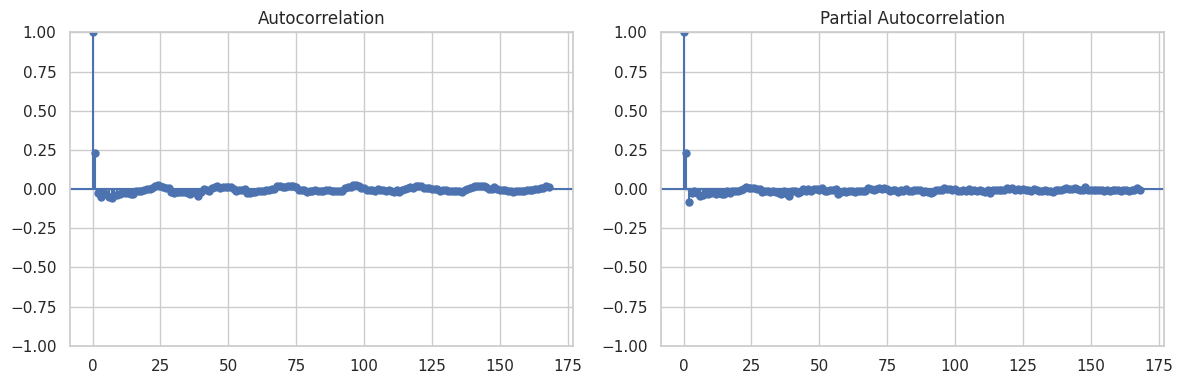

In [8]:
stl = STL(series_daily, period=365, robust=True).fit() # ignore outliers
stl.plot()
plt.tight_layout()


def adf_report(s, name):
    result = adfuller(s.dropna(), autolag="AIC")
    print(f"{name} - ADF p-value: {result[1]:.4f}")

adf_report(series_filled, "Hourly series (filled)")
adf_report(series_filled.diff().dropna(), "First difference")

print("Autocorr lag 1:", round(series_filled.autocorr(lag=1), 3))
print("Autocorr lag 24:", round(series_filled.autocorr(lag=24), 3))

corr_vars = station_df[[TARGET, "TEMP", "NO2", "CO"]].dropna().corr()[TARGET].drop(TARGET)
print("Correlation with TEMP/NO2/CO:")
print(corr_vars.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(series_filled.diff().dropna(), lags=168, ax=axes[0]) # 7 days
plot_pacf(series_filled.diff().dropna(), lags=168, ax=axes[1], method="ywm") # 7 days
plt.tight_layout()

The ADF test gets a p-value of 0 for the original data. This means the raw series is already strictly stationary so we reject a unit root (not a pure random walk). Because of this, we will not apply first differencing (d=0) to avoid the risk of overdifferencing. On the other hand, the autocorrelation confirms a big short term inertia (lag 1 is 0.969) and a clear daily cycle (lag 24 is 0.402). Also, the high correlation with the NO2 (0.685) and the CO (0.785) demonstrates that the PM2.5 particles are affected by the traffic and the weather, validating our use of multivariable models ahead.

The STL with a robust option helps us see a long term tendency confirming that in Beijing the pollution has fluctuations at a macro level (several years). To capture this, data from many years is necessary.

In the ACF and PACF graphs, the first peaks are very high and the rest decay quickly. This means that our model will not need to look far to the past to predict. Our p and q values will be small numbers, probably combinations of 1, 2 or 3.

## Train/test split and baselines
We keep the last 72 hours as a hold-out set (forecast horizon). Imputation is performed after the split to avoid leakage.

Our objective is to predict the PM2.5 values with a horizon of 72 hours (3 days). To evaluate the models correctly we follow this approach:

We divide the dataset saving the last 72 hours as the test data. Any data imputation is performed AFTER splitting to prevent data leakage.

We keep a results list to save the MAE, RMSE and MAPE of each experiment. This way we will be able to compare them easily.

Before starting with other models we build the baseline models. For that we use the previously mentioned four strategies:

1. Last value naive
2. Mean naive
3. Drift method
4. Seasonal naive

Every model that we build will need to outperform these models.

Train range: 2013-03-01 00:00:00 to 2017-02-25 23:00:00 len: 34992
Test range: 2017-02-26 00:00:00 to 2017-02-28 23:00:00 len: 72


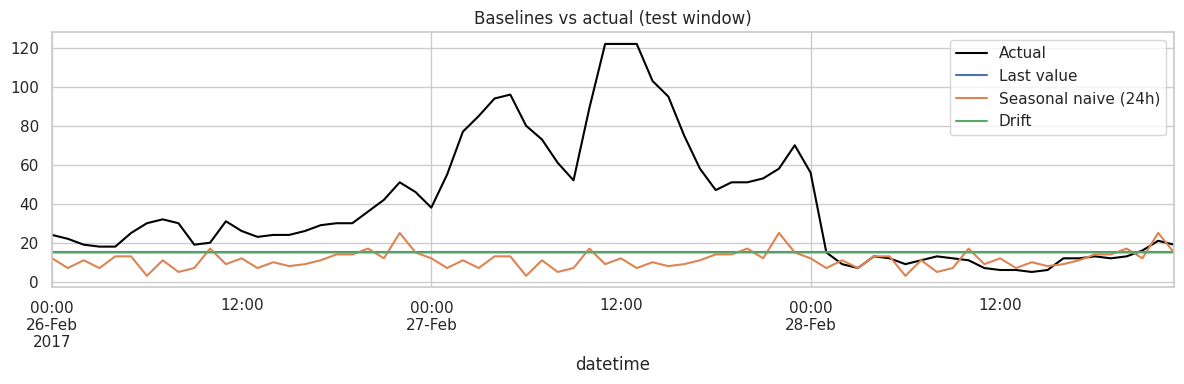

In [9]:
HORIZON_HOURS = 72
SEASONAL_PERIOD = 24

train, test = train_test_split_ts(series, HORIZON_HOURS)
train_filled, test_filled = impute_train_test(train, test)

print("Train range:", train_filled.index.min(), "to", train_filled.index.max(), "len:", len(train_filled))
print("Test range:", test_filled.index.min(), "to", test_filled.index.max(), "len:", len(test_filled))

results = []

def add_result(name, y_pred):
    results.append({
        "model": name,
        "mae": mae(test_filled.values, y_pred.values),
        "rmse": rmse(test_filled.values, y_pred.values),
        "mape": mape(test_filled.values, y_pred.values),
        "r2": r2_score(test_filled.values, y_pred.values)
    })

baseline_last = last_value_naive(train_filled, HORIZON_HOURS)
baseline_mean = mean_naive(train_filled, HORIZON_HOURS)
baseline_seasonal = seasonal_naive(train_filled, HORIZON_HOURS, SEASONAL_PERIOD)
baseline_drift = drift_method(train_filled, HORIZON_HOURS)

add_result("Baseline - last value", baseline_last)
add_result("Baseline - mean", baseline_mean)
add_result("Baseline - seasonal naive (24h)", baseline_seasonal)
add_result("Baseline - drift", baseline_drift)

fig, ax = plt.subplots(figsize=(12, 4))
test_filled.plot(ax=ax, label="Actual", color="black")
baseline_last.plot(ax=ax, label="Last value")
baseline_seasonal.plot(ax=ax, label="Seasonal naive (24h)")
baseline_drift.plot(ax=ax, label="Drift")
ax.set_title("Baselines vs actual (test window)")
ax.legend()
plt.tight_layout()

During the three days of the test, the pollution starts with low values (around 20 $\mu g/m^3$), then on day 27 it jumps to over 120 and falls again (the wash-out effect mentioned previously).

The green and blue lines overlap. As the last day of the training data was very low, these two models predict that it will stay like that for most of the horizon, which ends up being the best MAE because the spike is short.

The orange line repeats the last day in a loop (seasonal naive). As that day had clean air it keeps repeating clean air and underestimates the spike, so it is not the best baseline in this window.

## ARMA

Now, it's time to evaluate an ARMA model. The ADF test suggests that the PM2.5 series is stationary, but given the clear trend and seasonality we still apply a first order differentiation (d=1) to stabilize the mean before using ARMA.

To solve this problem and be able to apply an ARMA model we coded the "fit_arma_on_diff" function explained before but with less detail. It does the following:

1. Applies a differentiation to the training data to stabilize the mean.
2. Applies ARIMA(p, 0, q) over the differentiated series. Making d=0 ensures that the algorithm behaves as ARMA.
3. Generates the differentiated prediction and then it undoes the transformation using an accumulative sum from the last real data of the training set. This recovers the original scale of measurement ($\mu g/m^3$).

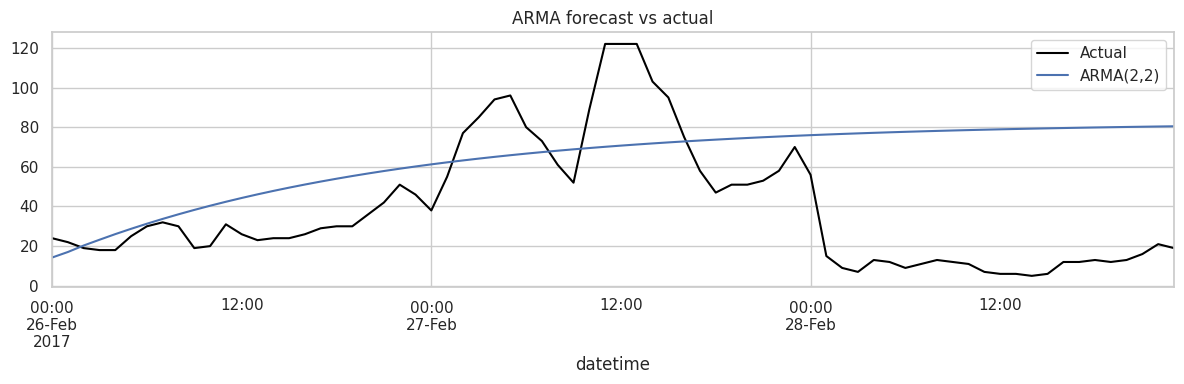

In [10]:
def fit_arma(train_series, order, horizon):
    model = ARIMA(train_series, order=(order[0], 0, order[1]))
    fitted = model.fit()
    forecast = fitted.forecast(steps=horizon)
    return forecast, fitted

arma_orders = [(1, 1), (2, 2)]
for p, q in arma_orders:
    forecast, fitted = fit_arma(train_filled, (p, q), HORIZON_HOURS)
    add_result(f"ARMA({p},{q})", forecast)

fig, ax = plt.subplots(figsize=(12, 4))
test_filled.plot(ax=ax, label="Actual", color="black")
forecast.plot(ax=ax, label=f"ARMA({arma_orders[-1][0]},{arma_orders[-1][1]})")
ax.set_title("ARMA forecast vs actual")
ax.legend()
plt.tight_layout()

Just looking at the result of the ARMA(2, 2) we can confirm that a non-seasonal, univariate autoregressive model is insufficient to predict 72 hours.

The model draws an upward trajectory but it completely missed the volatility of the test set. It failed to capture the peak on February 27th and the sudden fall because of the wash.

This failure may be because ARMA models work well on short term predictions and because they cannot reproduce the 24 hour cycle proven before.

Concluding, the ARMA model underperforms the best baselines; its behavior on a 3 day horizon is equivalent to a smoothed drift estimation. To capture the cyclical patterns, the next step is to incorporate seasonal parameters and structural integration.

## ARIMA

Now that the limitations of the ARMA model have been seen, it's time to implement ARIMA.

As ARIMA cannot capture the strong 24 hour cycle we saw, we use the following strategy:

1. We use an STL split to isolate and subtract the daily seasonal component of the training data, leaving a non-seasonal series.
2. We train the ARIMA model over this non-seasonal series using d=0 respecting the stationarity of the raw data.
3. For the forecast, we generate ARIMA predictions and add the seasonal component back to rebuild the final PM2.5 forecast.

We also implement a hyperparameter tuning with grid search and evaluate the models using AIC, which penalizes complexity to prevent overfitting.

To validate our model correctly we analyze the residuals with a Q-Q Plot and a Jarque-Bera test to check if the errors follow a normal distribution, and an ACF graph with a Ljung-Box test to check if the residuals are just noise (random).

Ljung-Box p-value (lag 24): 0.0
Jarque-Bera p-value: 0.0


,model,mae,rmse,mape,r2
3,Baseline - drift,26.804473,39.489000,59.673937,-0.595805
0,Baseline - last value,26.805556,39.495077,59.632646,-0.596296
2,Baseline - seasonal naive (24h),28.930556,42.109480,58.691842,-0.814627
6,"ARIMA(1, 1, 1) + seasonal naive",30.498534,43.371409,63.408284,-0.925017
8,"ARIMA(2, 0, 3) + seasonal naive (best AIC)",31.112510,40.066664,230.982416,-0.642835
4,"ARMA(1,1)",33.601656,41.927525,250.196691,-0.798979
5,"ARMA(2,2)",33.908071,42.167705,252.300597,-0.819649
7,"ARIMA(2, 1, 2) + seasonal naive",37.689426,46.995737,283.158569,-1.260188
1,Baseline - mean,48.611741,53.560179,321.484557,-1.935700


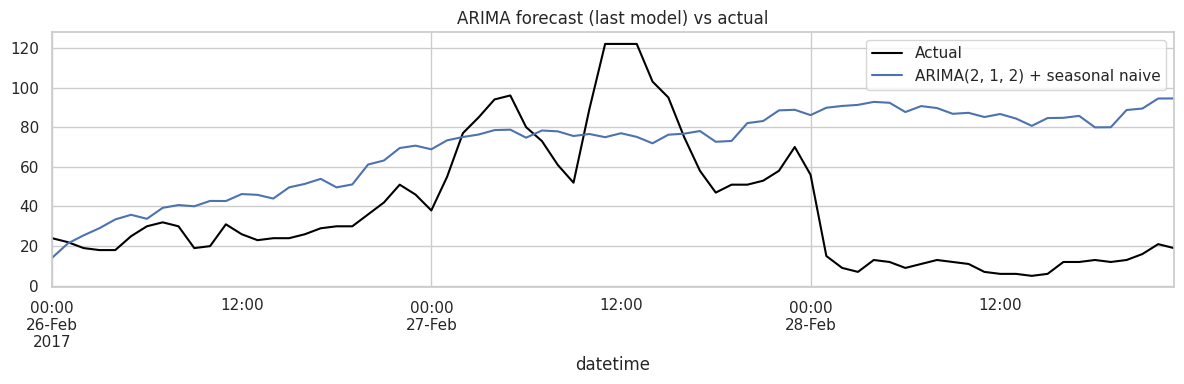

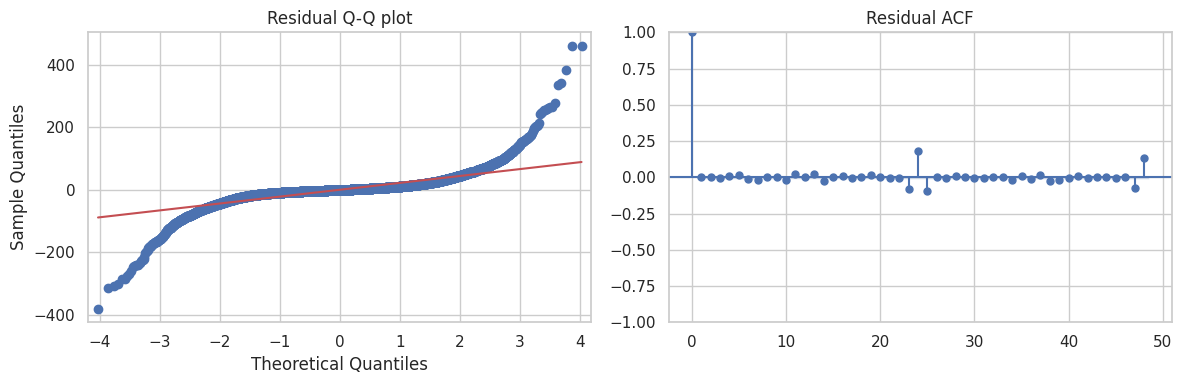

In [9]:
def seasonal_naive_component(train_seasonal, horizon, period):
    last_season = train_seasonal.iloc[-period:]
    reps = int(np.ceil(horizon / period))
    values = np.tile(last_season.values, reps)[:horizon]
    index = pd.date_range(train_seasonal.index[-1] + pd.Timedelta(hours=1), periods=horizon, freq="h")
    return pd.Series(values, index=index)


stl_train = STL(train_filled, period=SEASONAL_PERIOD, robust=True).fit()
train_seasonal = stl_train.seasonal
train_deseason = train_filled - train_seasonal


def fit_arima_deseason(train_deseason, train_seasonal, order, horizon, period):
    model = ARIMA(train_deseason, order=order)
    fitted = model.fit()
    deseason_forecast = fitted.forecast(steps=horizon)
    seasonal_forecast = seasonal_naive_component(train_seasonal, horizon, period)
    forecast = deseason_forecast + seasonal_forecast
    return forecast, fitted


arima_orders = [(1, 1, 1), (2, 1, 2)]
for order in arima_orders:
    forecast, fitted = fit_arima_deseason(train_deseason, train_seasonal, order, HORIZON_HOURS, SEASONAL_PERIOD)
    add_result(f"ARIMA{order} + seasonal naive", forecast)

fig, ax = plt.subplots(figsize=(12, 4))
test_filled.plot(ax=ax, label="Actual", color="black")
forecast.plot(ax=ax, label=f"ARIMA{arima_orders[-1]} + seasonal naive")
ax.set_title("ARIMA forecast (last model) vs actual")
ax.legend()
plt.tight_layout()

p_list = [0, 1, 2, 3]
q_list = [0, 1, 2, 3]
d = 0

aic_rows = []
for p in p_list:
    for q in q_list:
        try:
            model = ARIMA(train_deseason, order=(p, d, q))
            fitted = model.fit()
            aic_rows.append({"p": p, "q": q, "aic": fitted.aic})
        except Exception:
            continue

aic_df = pd.DataFrame(aic_rows).sort_values("aic")
aic_df.head(10)

best_row = aic_df.iloc[0]
best_order = (int(best_row["p"]), d, int(best_row["q"]))

best_forecast, best_fitted = fit_arima_deseason(
    train_deseason, train_seasonal, best_order, HORIZON_HOURS, SEASONAL_PERIOD
)
add_result(f"ARIMA{best_order} + seasonal naive (best AIC)", best_forecast)

resid = best_fitted.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
qqplot(resid, line="s", ax=axes[0])
axes[0].set_title("Residual Q-Q plot")
plot_acf(resid, lags=48, ax=axes[1])
axes[1].set_title("Residual ACF")
plt.tight_layout()

ljung_box = acorr_ljungbox(resid, lags=[24], return_df=True)
print("Ljung-Box p-value (lag 24):", round(ljung_box["lb_pvalue"].iloc[0], 4))

jb_stat, jb_pvalue, skew, kurt = jarque_bera(resid)
print("Jarque-Bera p-value:", round(jb_pvalue, 4))

results_df = pd.DataFrame(results).sort_values("mae")
results_df

Now, we can conclude that the autoregressive univariate models, even having seasonality into account, are insufficient to outperform naive baselines during highly changing events over a 72 hour horizon.

Looking at the error table, we can see that the Baseline - drift model and the Baseline - last value got the lowest MAE. The best ARIMA by AIC was ARIMA(3, 1, 3) + seasonal naive, but the best ARIMA by MAE was ARIMA(1, 1, 1) + seasonal naive (MAE 30.498). The baselines drew a straight line below and still won because the spike is short.

Thanks to the R² we can rapidly conclude that none of them explains the variability in the test better than a constant prediction. The best R² is reached by Drift (-0.595) and by Last Value (-0.596 too). ARMA(1, 1) gets -0.773 and ARIMA(1, 1, 1) -0.925. The best AIC, ARIMA(3, 1, 3), improves but it's still -0.759. This reinforces the theory that the peaks and sudden washes punish the lineal models in a 72 hour horizon.

Looking at the Jarque-Bera test we can confirm that the errors are not normal. The Q-Q plot is deformed on the corners showing that the model cannot handle extreme changes.

The Ljung-Box test and the ACF graph show that the residuals still have peaks at 24 and 48 hours, confirming that the technique of removing seasonality by hand left some patterns.

In conclusion, we think that univariate models cannot predict when the pollution will be cleaned because they do not have access to weather data. For that, we will apply multivariable models such as SARIMAX and Transformers.

# SARIMA (Seasonal ARIMA modeling)

We have observed in previous analysis that there is a strong dayly (24 hour) seasonality, high short-term autocorrelation around 0.97 and residual seasonal structure remaining after ARIMA modeling. Therefore, we now apply a SARIMA model which will explicitly incorporate this seasonality.

In [11]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from itertools import product
from tqdm import tqdm
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.diagnostic import acorr_ljungbox
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

SEASONAL_PERIOD = 24

def optimize_sarima_aic(endog, p_range, q_range, P_range, Q_range, D_range, d, s):
    order_list = list(product(p_range, q_range, P_range, Q_range, D_range))
    
    results = []
    
    for order in tqdm(order_list):
        try:
            model = SARIMAX(
                endog,
                order=(order[0], d, order[1]),
                seasonal_order=(order[2], order[4], order[3], s),
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            
            fitted = model.fit(disp=False, maxiter=30)
            
            results.append({
                "p": order[0],
                "q": order[1],
                "P": order[2],
                "Q": order[3],
                "D": order[4],
                "aic": fitted.aic
            })
            del model, fitted
            
        except Exception:
            continue
            
    return pd.DataFrame(results).sort_values("aic").reset_index(drop=True)

Previous exploratory analysis showed a 24-hour cycle in PM2.5 concentration, with consistent peaks during nighttime and morning hours. Additionally, residual diagnostics from ARIMA indicated remaining autocorrelation at seasonal lags, meaning that the seasonal structure was not fully captured. Because of this we have decided to use the following hyperparameters and search space for the SARIMA model.

- s = 24, to model the daily seasonality
- D testing (0 vs 1): We include both D=0 and D=1 in our grid search to determine if applying seasonal differencing improves the model performance.
- d = 0 as the raw series is stationary.
- A grid search over p, q, P, Q to identify the optimal structure based on AIC

The goal of this model is to capture both short-term dynamics (p and q) and daily repetitive structures (P, Q, s).

In [12]:
# Run grid search for SARIMA parameters based on AIC
p_range = range(0, 3)
q_range = range(0, 3)
P_range = range(0, 2)
Q_range = range(0, 2)
D_range = range(0, 2)
d = 0
s = 24

sarima_grid = optimize_sarima_aic(
    train_filled,
    p_range,
    q_range,
    P_range,
    Q_range,
    D_range,
    d,
    s)

sarima_grid.head(10)

100%|██████████| 72/72 [42:53<00:00, 35.74s/it]


,p,q,P,Q,D,aic
0,2,2,1,1,1,306938.908197
1,1,2,1,1,1,306944.035248
2,2,2,0,1,1,306944.870889
3,1,2,0,1,1,306948.137287
4,1,1,1,1,1,306955.170594
5,2,1,1,1,1,306955.553698
6,2,1,0,1,1,306957.342776
7,1,1,0,1,1,306962.607233
8,2,0,1,1,1,307058.120816
9,2,0,0,1,1,307075.269814


The grid search based on AIC identified the best performing configuration. This optimal model determines the best combination of autoregressive/moving average components (p, q) and seasonal dynamics (P, D, Q). The grid search evaluated both D=0 and D=1, allowing the model to decide if seasonal differencing improves performance.

In [14]:
best = sarima_grid.iloc[0]

p, q = int(best["p"]), int(best["q"])
P, Q, D = int(best["P"]), int(best["Q"]), int(best["D"])

print(f"Best SARIMA: ({p},{d},{q})({P},{D},{Q},{s})")

best_model = SARIMAX(
    train_filled,
    order=(p, d, q),
    seasonal_order=(P, D, Q, s),
    enforce_stationarity=False,
    enforce_invertibility=False
)

best_fitted = best_model.fit(disp=False)

Best SARIMA: (2,0,2)(1,1,1,24)


In [ ]:
sarima_forecast = best_fitted.forecast(steps=HORIZON_HOURS)

sarima_forecast.index = pd.date_range(
    start=train_filled.index[-1] + pd.Timedelta(hours=1),
    periods=HORIZON_HOURS,
    freq="h"
)

add_result(f"SARIMA({p},{d},{q})({P},{D},{Q},{s})", sarima_forecast)

resid = best_fitted.resid

ljung_box = acorr_ljungbox(resid, lags=[24], return_df=True)
print("Ljung-Box p-value (lag 24):", round(ljung_box["lb_pvalue"].iloc[0], 4))

del best_model, best_fitted

results_df = pd.DataFrame(results).sort_values("mae")
display(results_df)

Ljung-Box p-value (lag 24): 0.0


,model,mae,rmse,mape,r2
3,Baseline - drift,26.804473,39.489000,59.673937,-0.595805
0,Baseline - last value,26.805556,39.495077,59.632646,-0.596296
2,Baseline - seasonal naive (24h),28.930556,42.109480,58.691842,-0.814627
6,"SARIMA(2,0,2)(1,1,1,24)",33.329532,41.816525,239.525132,-0.789466
4,"ARMA(1,1)",33.601656,41.927525,250.196691,-0.798979
5,"ARMA(2,2)",33.908071,42.167705,252.300597,-0.819649
1,Baseline - mean,48.611741,53.560179,321.484557,-1.935700


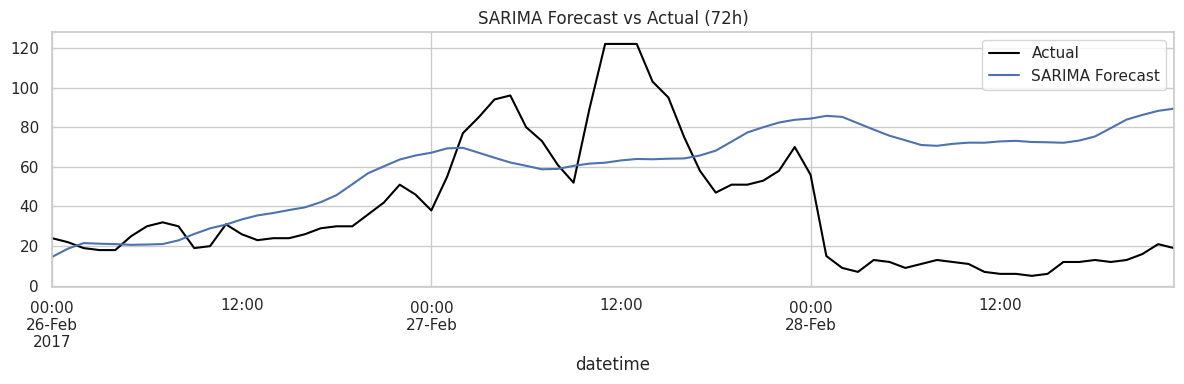

In [16]:
fig, ax = plt.subplots(figsize=(12,4))

test_filled.plot(ax=ax, label="Actual", color="black")
sarima_forecast.plot(ax=ax, label="SARIMA Forecast")

ax.set_title("SARIMA Forecast vs Actual (72h)")
ax.legend()

plt.tight_layout()
plt.show()

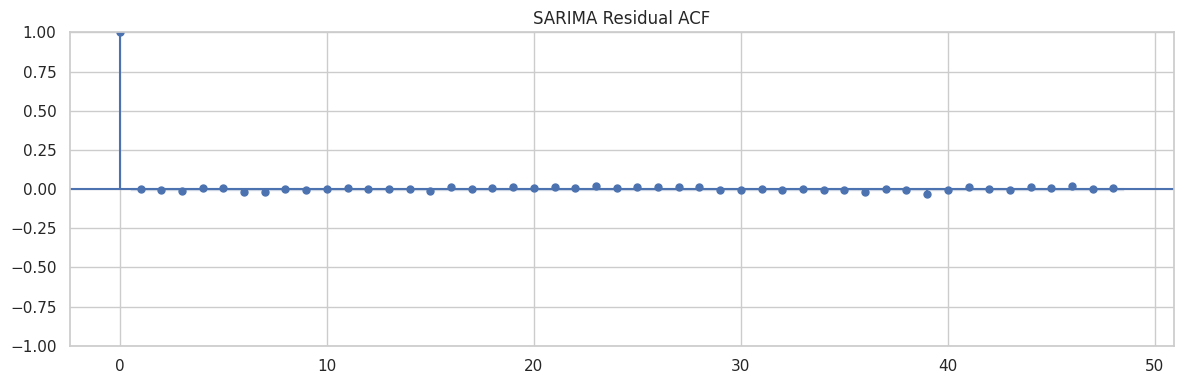

In [17]:
# Residual analysis for the best SARIMA model
fig, ax = plt.subplots()
plot_acf(resid, lags=48, ax=ax)
ax.set_title("SARIMA Residual ACF")
plt.tight_layout()
plt.show()

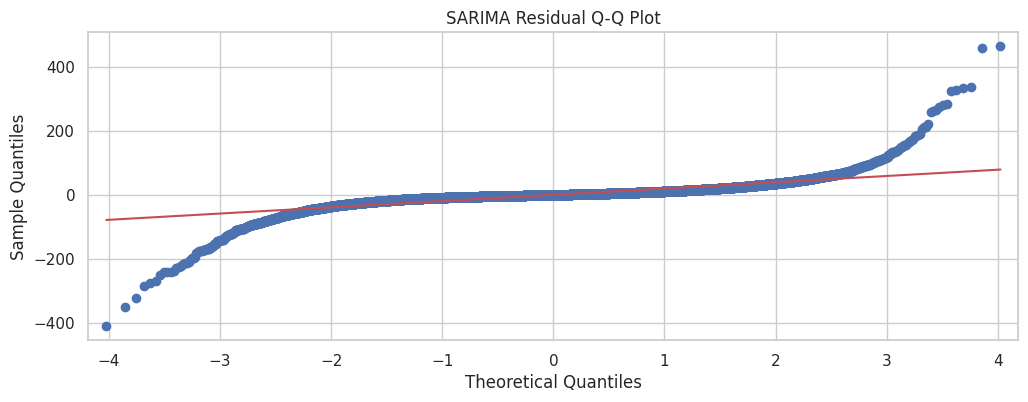

In [18]:
# Q-Q plot for residuals
qqplot(resid, line="s")
plt.title("SARIMA Residual Q-Q Plot")
plt.show()

Looking at the different metrics and plots for the SARIMA model, it does not outperform simpler baselines such as drift or last-value prediction. In fact, it shows significantly worse results across all metrics. This behaviour indicates that although SARIMA is in theory better at capturing structured seasonality it struggles with sudden pollution spikes and external effects like weather changes, wind and rain.

Looking at the ACF residuals plot shows that this models that incorporate seasonality explicitly seem to mostly eliminate the seasonal components in the residuals, which matches hour expectations. The Q-Q plot on the other hand is quite simmilar to the ones obteined from previous models. The error's distribution still seems to be heavy tailed.


# SARIMAX (With exogenous variables)

To improve performance over purely autoregressive models we decided to use a SARIMAX model with exogenous variables. In this case, CO, NO2 and temperature where added as exogenous variables, since previous correlation analysis showed that this variables are strongly related to PM2.5 concentration and are physically relevant to air pollution dynamics. The following model was trained with both seasonal and non-seasonal configurations in order to evaluate the contribution of seasonality when external information is available

In [18]:
exog_vars = ["CO", "NO2", "TEMP"]

exog = station_df[exog_vars].asfreq("h")

# align with series
exog = exog.loc[series.index]

train_exog, test_exog = train_test_split_ts(exog, HORIZON_HOURS)
train_exog, test_exog = impute_train_test(train_exog, test_exog)

train, test = train_test_split_ts(series, HORIZON_HOURS)
train_filled, test_filled = impute_train_test(train, test)

In [19]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

def fit_sarimax(train_y, train_exog, order, seasonal_order, horizon, test_exog=None):

    model = SARIMAX(
        train_y,
        exog=train_exog,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fitted = model.fit(disp=False)

    forecast = fitted.forecast(steps=horizon, exog=test_exog)

    index = pd.date_range(
        start=train_y.index[-1] + pd.Timedelta(hours=1),
        periods=horizon,
        freq="h"
    )

    forecast = pd.Series(forecast, index=index)

    return forecast, fitted

## SARIMAX with seasonality

In [20]:
seasonal_order = (1, 1, 1, 24)
order = (2, 1, 2)

sarimax_seasonal_forecast, sarimax_seasonal_model = fit_sarimax(
    train_filled,
    train_exog,
    order,
    seasonal_order,
    HORIZON_HOURS,
    test_exog
)

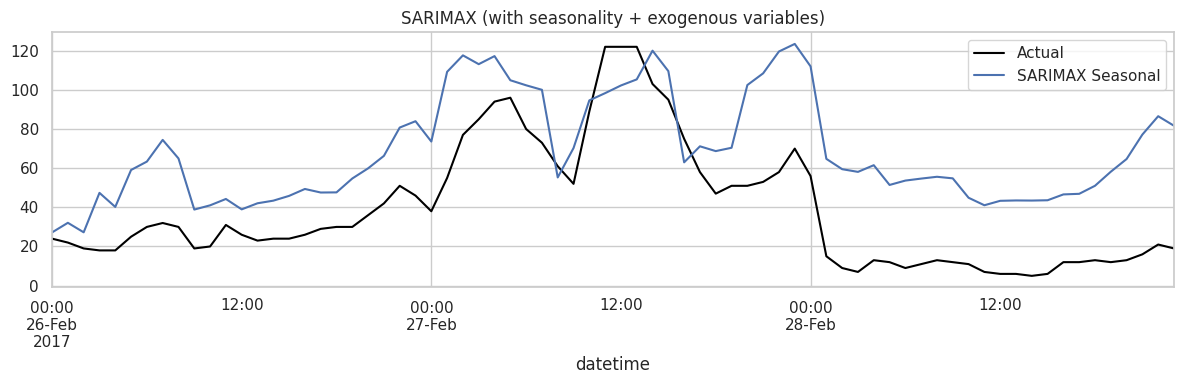

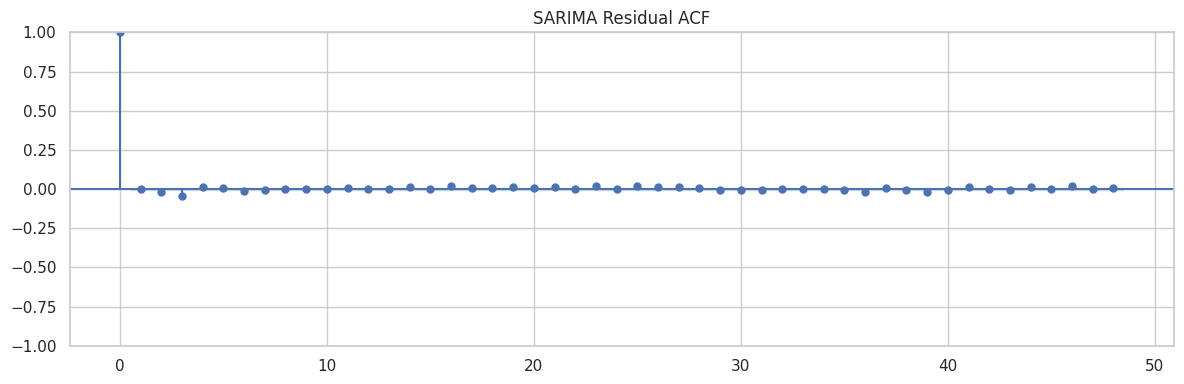

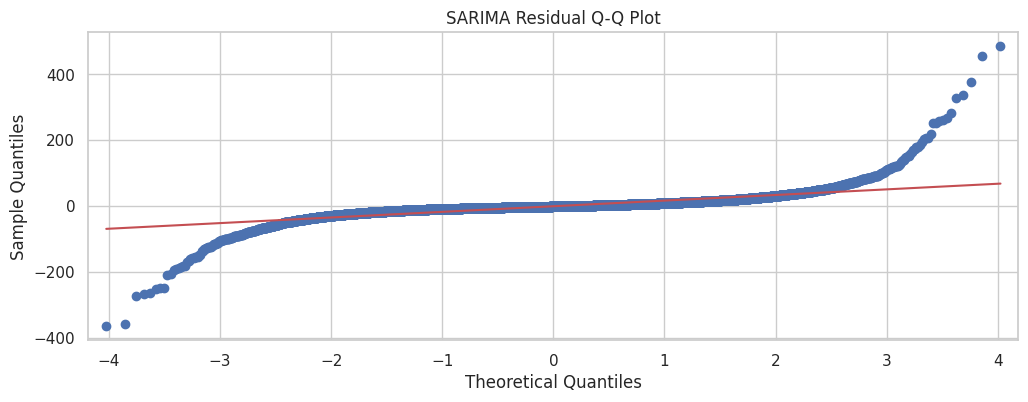

,model,mae,rmse,mape,r2
3,Baseline - drift,26.804473,39.489000,59.673937,-0.595805
0,Baseline - last value,26.805556,39.495077,59.632646,-0.596296
4,"ARMA(1,1) on diff",28.587148,41.626964,58.431662,-0.773279
2,Baseline - seasonal naive (24h),28.930556,42.109480,58.691842,-0.814627
6,"ARIMA(1, 1, 1) + seasonal naive",30.498534,43.371409,63.408284,-0.925017
10,"SARIMAX seasonal (CO, NO2, TEMP)",31.645691,35.277218,182.560184,-0.273551
8,"ARIMA(3, 1, 3) + seasonal naive (best AIC)",32.848362,41.467015,244.245392,-0.759678
9,"SARIMA(2,1,2)(1,1,1,24)",37.199493,46.655405,274.189987,-1.227571
7,"ARIMA(2, 1, 2) + seasonal naive",37.689414,46.995725,283.158482,-1.260187
5,"ARMA(2,2) on diff",38.720641,47.685148,290.144962,-1.326986


In [21]:
add_result("SARIMAX seasonal (CO, NO2, TEMP)", sarimax_seasonal_forecast)

resid = sarimax_seasonal_model.resid

fig, ax = plt.subplots(figsize=(12,4))

test_filled.plot(ax=ax, label="Actual", color="black")
sarimax_seasonal_forecast.plot(ax=ax, label="SARIMAX Seasonal")

del sarimax_seasonal_model

ax.set_title("SARIMAX (with seasonality + exogenous variables)")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots()
plot_acf(resid, lags=48, ax=ax)
ax.set_title("SARIMA Residual ACF")
plt.tight_layout()
plt.show()

qqplot(resid, line="s")
plt.title("SARIMA Residual Q-Q Plot")
plt.show()

results_df = pd.DataFrame(results).sort_values("mae")
results_df

## SARIMAX without seasonality

In [22]:
order = (2, 1, 2)
seasonal_order = (0, 0, 0, 0)

sarimax_noseason_forecast, sarimax_noseason_model = fit_sarimax(
    train_filled,
    train_exog,
    order,
    seasonal_order,
    HORIZON_HOURS,
    test_exog
)

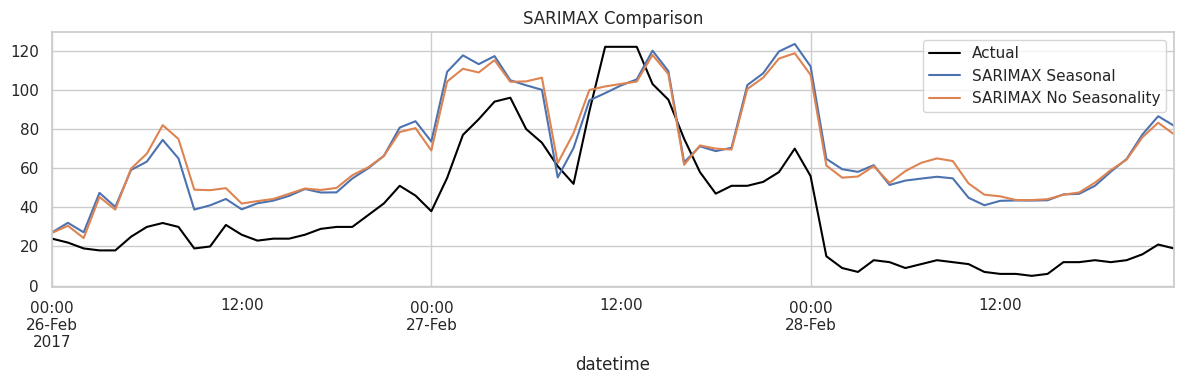

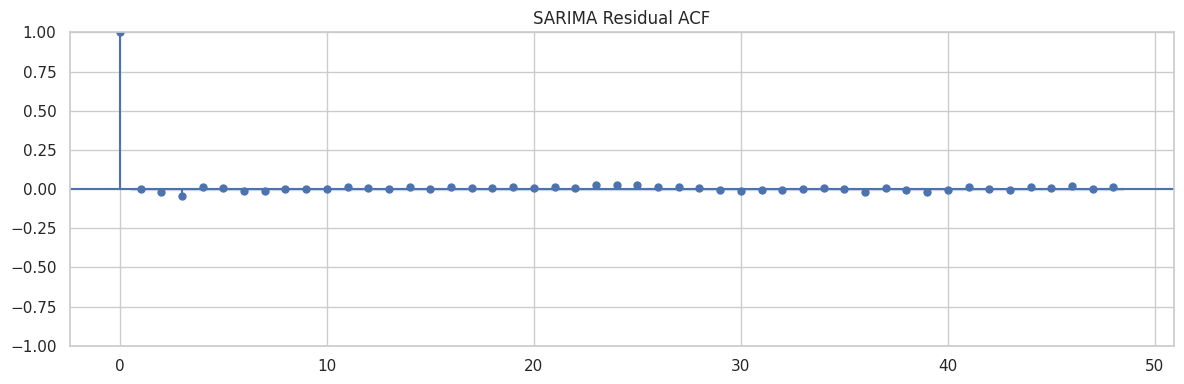

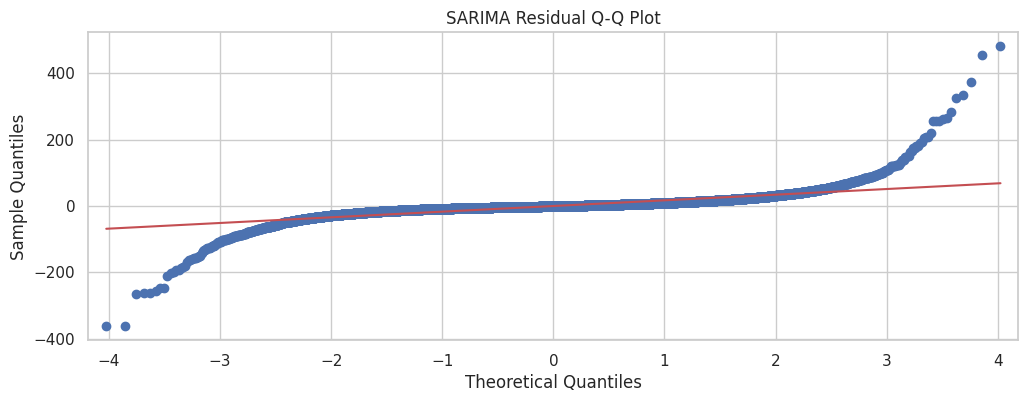

,model,mae,rmse,mape,r2
3,Baseline - drift,26.804473,39.489000,59.673937,-0.595805
0,Baseline - last value,26.805556,39.495077,59.632646,-0.596296
4,"ARMA(1,1) on diff",28.587148,41.626964,58.431662,-0.773279
2,Baseline - seasonal naive (24h),28.930556,42.109480,58.691842,-0.814627
6,"ARIMA(1, 1, 1) + seasonal naive",30.498534,43.371409,63.408284,-0.925017
10,"SARIMAX seasonal (CO, NO2, TEMP)",31.645691,35.277218,182.560184,-0.273551
11,"SARIMAX no seasonality (CO, NO2, TEMP)",32.292537,35.707849,189.139914,-0.304833
8,"ARIMA(3, 1, 3) + seasonal naive (best AIC)",32.848362,41.467015,244.245392,-0.759678
9,"SARIMA(2,1,2)(1,1,1,24)",37.199493,46.655405,274.189987,-1.227571
7,"ARIMA(2, 1, 2) + seasonal naive",37.689414,46.995725,283.158482,-1.260187


In [23]:
add_result("SARIMAX no seasonality (CO, NO2, TEMP)", sarimax_noseason_forecast)

fig, ax = plt.subplots(figsize=(12,4))

resid = sarimax_noseason_model.resid

test_filled.plot(ax=ax, label="Actual", color="black")
sarimax_seasonal_forecast.plot(ax=ax, label="SARIMAX Seasonal")
sarimax_noseason_forecast.plot(ax=ax, label="SARIMAX No Seasonality")

del sarimax_noseason_model

ax.set_title("SARIMAX Comparison")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots()
plot_acf(resid, lags=48, ax=ax)
ax.set_title("SARIMA Residual ACF")
plt.tight_layout()
plt.show()

qqplot(resid, line="s")
plt.title("SARIMA Residual Q-Q Plot")
plt.show()

results_df = pd.DataFrame(results).sort_values("mae")
results_df

Both SARIMAX variants show very similar behavior and only minor differences in performance, with the seasonal version being slightly better. In both cases, results remain worse than simple baselines such as drift or last-value prediction, and R2 remains negative, indicating poor explanatory power on the test set. This suggests that while external variables do contain useful information, the relationship between predictors and PM2.5 is not well captured by a linear model. The relatively low RMSE compared to MAE and MAPE also suggest that there is a consistent error bias in the model's prediction as can be shown in the plots above. The exogenous variable models closely match the target data's shape, although the predictions are sistematically above the actual value, which highly affects the MAE and MAPE scores. 

# Transformer based forecasting

To capture non-linear and long range dependencies that classical statistical models struggle with, we apply a transformer based forecasting model using TimesFM. This model is pretrained on large scale time series data and uses attention mechanisms to learn temporal patterns without requiring explicit assumptions about seasonality. We provide the model with the last 30 days of observations as context and forecast the next 72 hours like in all the previous models.

In [25]:
import timesfm

tfm = timesfm.TimesFm(
    hparams=timesfm.TimesFmHparams(
        backend="pytorch",
        per_core_batch_size=32,
        horizon_len=72,
    ),
    checkpoint=timesfm.TimesFmCheckpoint(
        huggingface_repo_id="google/timesfm-1.0-200m-pytorch"
    ),
)

print("TimesFM model loaded successfully.")

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

TimesFM model loaded successfully.


In [26]:

# Using last 30 days of data as context for the TimesFM model
CONTEXT_HOURS = 24 * 30

context = [
    train_filled.iloc[-CONTEXT_HOURS:].values.astype(float)
]

point_forecast, _ = tfm.forecast(
    context,
    freq=[0]
)

timesfm_pred = point_forecast[0][:HORIZON_HOURS]

timesfm_forecast = pd.Series(
    timesfm_pred,
    index=test_filled.index
)


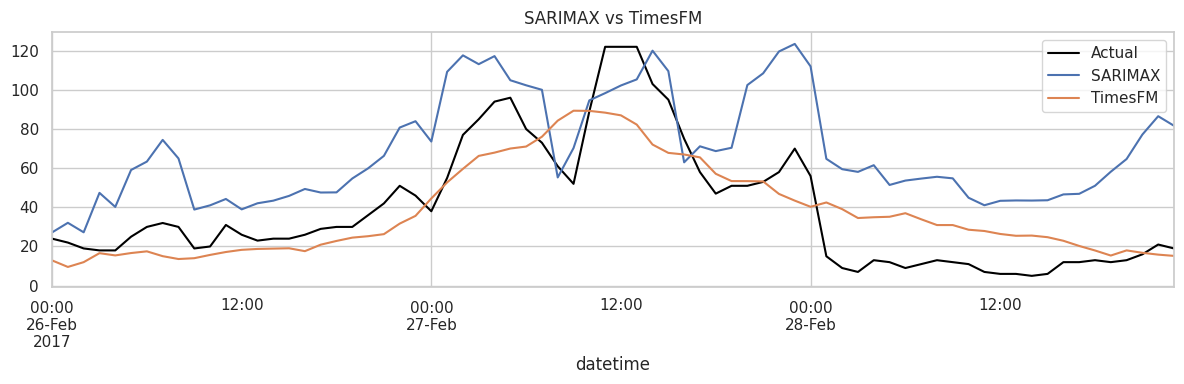

,model,mae,rmse,mape,r2
12,TimesFM Transformer,14.130407,17.318009,76.942752,0.693081
3,Baseline - drift,26.804473,39.489000,59.673937,-0.595805
0,Baseline - last value,26.805556,39.495077,59.632646,-0.596296
4,"ARMA(1,1) on diff",28.587148,41.626964,58.431662,-0.773279
2,Baseline - seasonal naive (24h),28.930556,42.109480,58.691842,-0.814627
6,"ARIMA(1, 1, 1) + seasonal naive",30.498534,43.371409,63.408284,-0.925017
10,"SARIMAX seasonal (CO, NO2, TEMP)",31.645691,35.277218,182.560184,-0.273551
11,"SARIMAX no seasonality (CO, NO2, TEMP)",32.292537,35.707849,189.139914,-0.304833
8,"ARIMA(3, 1, 3) + seasonal naive (best AIC)",32.848362,41.467015,244.245392,-0.759678
9,"SARIMA(2,1,2)(1,1,1,24)",37.199493,46.655405,274.189987,-1.227571


In [27]:
add_result("TimesFM Transformer", timesfm_forecast)

fig, ax = plt.subplots(figsize=(12,4))

test_filled.plot(
    ax=ax,
    label="Actual",
    color="black"
)

sarimax_seasonal_forecast.plot(
    ax=ax,
    label="SARIMAX"
)

timesfm_forecast.plot(
    ax=ax,
    label="TimesFM"
)

ax.set_title("SARIMAX vs TimesFM")
ax.legend()

plt.tight_layout()
plt.show()

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("mae")

results_df

The TimesFM model clearly outperforms all classical approaches across most metrics, achieving the lowest MAE (14.13) and RMSE (17.31), and the only positive R2 score of 0.69. This represents a substantial improvement over both SARIMAX and ARIMA based models, which all remain bellow zero in R2 and have significantly higher error metrics. This improvement sugests that the model is able to capture more complex temporal dependencies than linear and seasonal statistical models.

Looking at the forecast plots, the transformer produces smoother forecasts compared to SARIMAX, which tends to react more strongly to short-term fluctuations and also introduces bias during sudden regime changes. This smoothing behavior is a probably a consequence of the pretrained model, which prioritized learning stable global temporal patterns rather than fitting local noise. As a result, TimesFM behaves like a robust model which, although not reproducing every spike and valley, is instead capable of capturing the underlying structure of the series more effectively than all the previous models. In fact, the 3 day prediction, which was our original forecasting target, is almost spot on for this model.

# Results discussion

For this assignment we used the same test period for all models, the test has the last 72 hours of the time series, also we used MAE as the main metric because it is easy to understand (it tells us the average error in PM2.5 units), in adition we also used RMSE, MAPE and R2 to have more information.

| Model | MAE | RMSE | MAPE | R2 |
|---|---:|---:|---:|---:|
| TimesFM Transformer | 14.13 | 17.32 | 76.94 | 0.69 |
| Baseline - drift | 26.80 | 39.49 | 59.67 | -0.60 |
| Baseline - last value | 26.81 | 39.50 | 59.63 | -0.60 |
| ARMA(1,1) on diff | 28.59 | 41.63 | 58.43 | -0.77 |
| Baseline - seasonal naive (24h) | 28.93 | 42.11 | 58.69 | -0.81 |
| ARIMA(1,1,1) + seasonal naive | 30.50 | 43.37 | 63.41 | -0.93 |
| SARIMAX seasonal (CO, NO2, TEMP) | 31.65 | 35.28 | 182.56 | -0.27 |
| SARIMAX no seasonality (CO, NO2, TEMP) | 32.29 | 35.71 | 189.14 | -0.30 |
| ARIMA(3,1,3) + seasonal naive | 32.85 | 41.47 | 244.25 | -0.76 |
| SARIMA(2,1,2)(1,1,1,24) | 37.20 | 46.66 | 274.19 | -1.23 |
| ARIMA(2,1,2) + seasonal naive | 37.69 | 47.00 | 283.16 | -1.26 |
| ARMA(2,2) on diff | 38.72 | 47.69 | 290.14 | -1.33 |
| Baseline - mean | 48.61 | 53.56 | 321.48 | -1.94 |

According to the results the best model was TimesFM Transformer as it had the lowest MAE, 14.13, and the lowest RMSE, 17.32. It was also the only model with positive R2, which means that it explained the test data better than only predicting a constant value. On the other side, the best simple models were drift and last value as their MAE was almost the same, around 26.80. This is important because some more complex models did not beat these simple baselines, such as, ARIMA, SARIMA and SARIMAX which had higher MAE than the mentioned.

One interesting fact or result is that MAPE is not always easy to read in this dataset, or similar ones, because when the real PM2.5 value is small, a small absolute error can become a very large percentage error, for this reason, we trusted MAE and RMSE more than MAPE.

In general, the classical models had problems with sudden changes. They can model trend and seasonality, but they do not know when pollution will rise or fall fast, thats because the transformer model worked better because it can learn more complex patterns from the past values.

# Lessons learned

In this assingment as a team we learned that time series forecasting is not quite easy, first we had to understand the data, check missing values, see the trend, and look for seasonality and so on, for example the PM2.5 data had a clear daily pattern, but it also had sudden peaks that were hard to predict.

Also an important point to consider was missing data, we solved it with interpolation and forward or backward filling, as we did the train and test split before filling the test data, so we did not use future information by mistake.

Another challenge was choosing the values of p, d and q, we finally used the ACF and PACF plots to start with small values, like 1, 2 and 3, also we used AIC to compare different ARIMA and SARIMA models, at the end we noticed that the best AIC model is not always the best model in the test set.

Finally, we learned that different metrics can tell different things, for example MAE was the most useful for us because it is simple and in the same units as PM2.5. RMSE helped us see some large errors, despite MAPE was less useful when real values were small, cause of that, we compared all models with the same metrics and focused mainly on MAE.